# Swiggy Sales Analysis

### Import Libraries

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [52]:
df=pd.read_excel("D:/1.My Self Learn_Path/1.Data Analysis/swiggy-sales-data-analysis-python project/swiggy_data.xlsx")

In [53]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [54]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


### Metadata

In [55]:
print("No of Rows : ",df.shape[0])

No of Rows :  197430


In [56]:
print("No of Fields : ",df.shape[1])

No of Fields :  10


In [57]:
df.info

<bound method DataFrame.info of             State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar        Snack   
1                    Kengeri  Recommended   
2   

In [58]:
df.shape

(197430, 10)

### Data Types

In [59]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [60]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


# KPI's

### Total Revenue / Total Sales

In [61]:
total_sales = df["Price (INR)"].sum()
print("Total Sales : " ,round(total_sales,2))

Total Sales :  53012505.77


### Average Rating

In [62]:
avg_rating = df["Rating"].mean()
print("Average Rating : " ,round(avg_rating,1))

Average Rating :  4.3


### Average Order Value (AoV)

In [63]:
aov = df["Price (INR)"].mean()
print("Average Order Value : " ,round(aov,2))

Average Order Value :  268.51


### Ratings Count

In [64]:
rating_count = df["Rating Count"].sum()
print("Ratings Count : " ,rating_count)

Ratings Count :  5591574


### Total Orders

In [65]:
total_orders = len(df)
print("Total Orders : ",total_orders)

Total Orders :  197430


# Charts

### Monthly Sales Trend

  Year_Month  Price (INR)
0    2025-01   6825186.03
1    2025-02   6269105.67
2    2025-03   6573530.07
3    2025-04   6594515.00
4    2025-05   6793558.40
5    2025-06   6514183.19
6    2025-07   6650965.51
7    2025-08   6791461.90


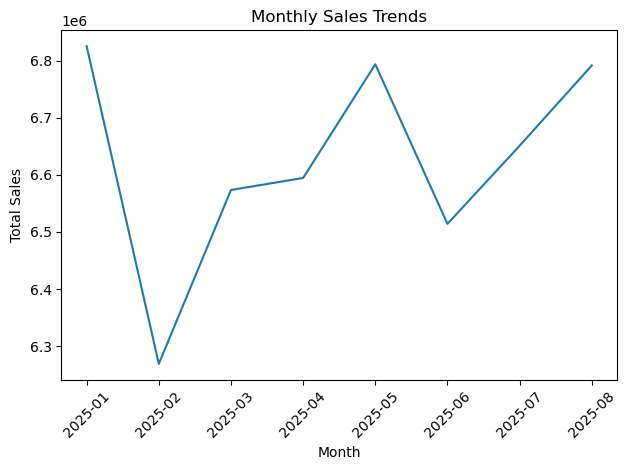

In [66]:
df["Order Date"] =pd.to_datetime(df["Order Date"])

df["Year_Month"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_revenue = df.groupby("Year_Month")["Price (INR)"].sum().reset_index()

print(monthly_revenue)

plt.figure()
plt.plot(monthly_revenue["Year_Month"], monthly_revenue["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trends")
plt.tight_layout()
plt.show()


### Daily Sales Trend


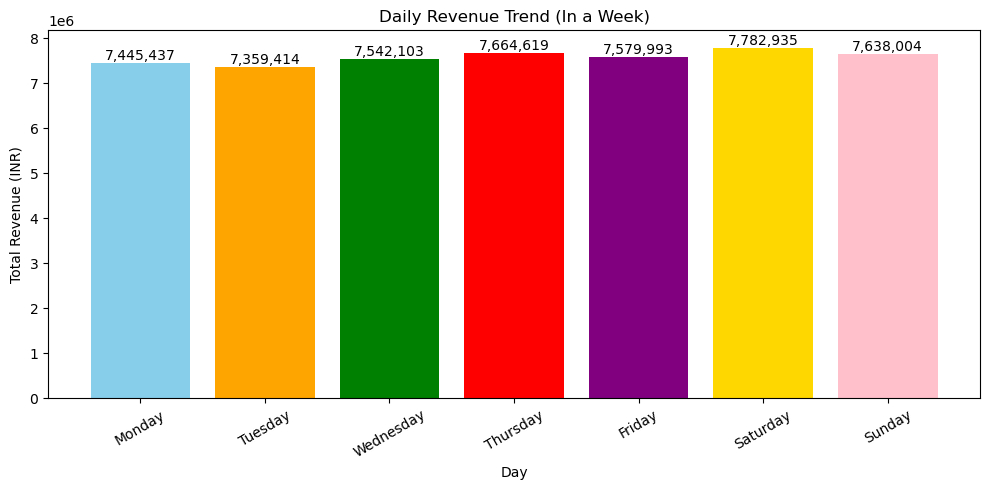

In [67]:
# Create DayName column from Order Date
df["DayName"] = df["Order Date"].dt.day_name()


# Calculate total revenue by each day of the week
daily_revenue = (
    df.groupby("DayName")["Price (INR)"]
    .sum()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)


# Create figure
plt.figure(figsize=(10, 5))


# Create bar chart with different colors
bars = plt.bar(
    daily_revenue.index,
    daily_revenue.values,
    color=[
        "skyblue",
        "orange",
        "green",
        "red",
        "purple",
        "gold",
        "pink"
    ]
)


# Add revenue labels on top of each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,     # X position
        bar.get_height(),                    # Y position
        f"{bar.get_height():,.0f}",           # Label value
        ha="center",                         # Horizontal alignment
        va="bottom"                          # Vertical alignment
    )


# Add chart title and axis labels
plt.title("Daily Revenue Trend (In a Week)")
plt.xlabel("Day")
plt.ylabel("Total Revenue (INR)")


# Rotate day names for readability
plt.xticks(rotation=30)


# Adjust spacing
plt.tight_layout()


# Display chart
plt.show()

### Revenue by Food Category (Veg/Non Veg)

In [68]:
non_veg_keywords = [
    "chicken", "egg", "fish","mutton","prawn","biriyani",
    "kabab","kebab","non-veg","non veg"
]

df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains(" | ".join(non_veg_keywords), na=False),
    "Non Veg", "Veg"
)



In [69]:
food_revenue = (
    df.groupby("Food Category")["Price (INR)"].sum().reset_index()
)

In [70]:
fig =px.pie(
    food_revenue,
    values="Price (INR)",
    names = "Food Category",
    hole = 0.5,
    title = "Revenue Contribution : Veg vs Non Veg",
)

fig.update_traces(
    textinfo = "percent+label",
    pull =[0.05,0]
)

fig.update_layout(
    height = 500,
    margin = dict(t=60,b=40,l=40,r=40)
)

fig.show()

### Top 5 states in Revenue

In [71]:
# --- D. Top 5 States in Revenue ---
state_revenue = df.groupby('State')['Price (INR)'].sum().sort_values(ascending=False).head(5).reset_index()

fig2 = px.bar(state_revenue, x='Price (INR)', y='State', orientation='h', title='Top 5 States by Revenue', height=450)
fig2.update_yaxes(autorange="reversed")
fig2.show()

### Tpo 5 Dishes

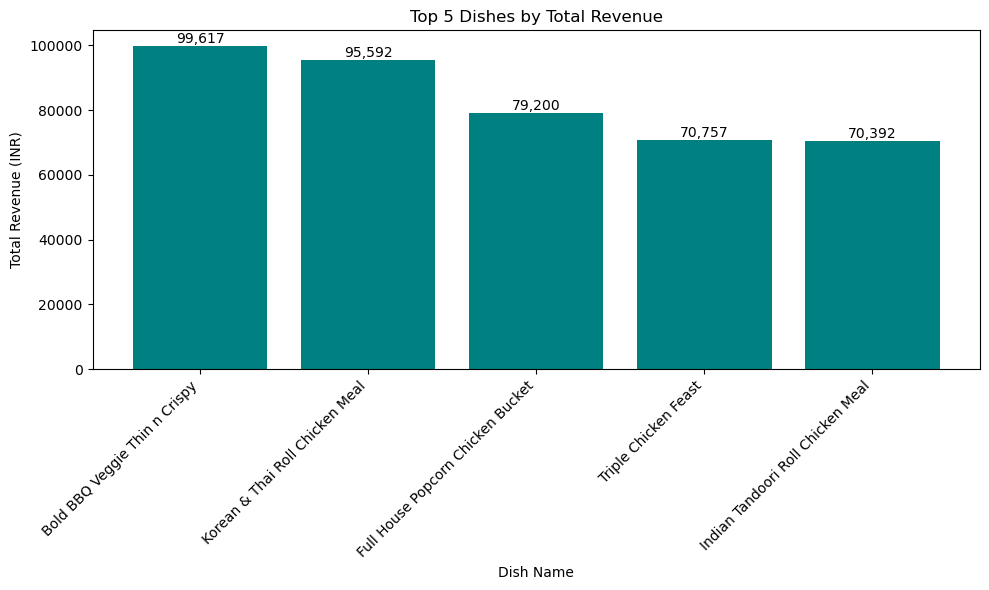

In [72]:
# Top 5 dishes by total revenue - vertical bar chart using matplotlib
top_5_dishes = (
    df.groupby('Dish Name')['Price (INR)']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10, 6))
bars = plt.bar(top_5_dishes.index, top_5_dishes.values, color='teal')
plt.title('Top 5 Dishes by Total Revenue')
plt.xlabel('Dish Name')
plt.ylabel('Total Revenue (INR)')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()